e# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [3]:
import pandas as pd

df_clean = pd.read_csv("Indoor_Plant_Health_and_Growth_Factors.csv")

print(df_clean.head())
print(df_clean.shape)
print(df_clean.columns)


                 Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
0  Sansevieria cylindrica      17.39          17                 8   
1               Aloe vera       9.84          31                 9   
2            Ficus lyrata      19.82          40                 8   
3      Monstera deliciosa      37.08          11                 1   
4            Ficus lyrata       2.96          26                 3   

       Health_Notes  Watering_Amount_ml  Watering_Frequency_days  \
0  Yellowing leaves                 205                        3   
1               NaN                 191                        1   
2    Brittle leaves                 477                        5   
3           New bud                 207                        1   
4           Wilting                 465                        2   

                   Sunlight_Exposure  Room_Temperature_C  Humidity_%  \
0              3h direct morning sun                21.7        77.5   
1              3h direct m

### Load and Inspect the Data

The first step is to load the dataset from the CSV file into a pandas DataFrame. We'll then perform an initial inspection to understand its structure, including viewing the first few rows, checking the dimensions (number of rows and columns), and listing the column names. This helps to get a first impression of the data we are working with.

### Check Data Types and Missing Values

Next, we'll examine the data types of each column and check for any missing values. This is a crucial step to identify any inconsistencies in the data, such as numbers being stored as text, or to see how much data is missing, which might require imputation or removal of rows/columns.

In [4]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Plant_ID                 1000 non-null   object 
 1   Height_cm                1000 non-null   float64
 2   Leaf_Count               1000 non-null   int64  
 3   New_Growth_Count         1000 non-null   int64  
 4   Health_Notes             882 non-null    object 
 5   Watering_Amount_ml       1000 non-null   int64  
 6   Watering_Frequency_days  1000 non-null   int64  
 7   Sunlight_Exposure        1000 non-null   object 
 8   Room_Temperature_C       1000 non-null   float64
 9   Humidity_%               1000 non-null   float64
 10  Fertilizer_Type          805 non-null    object 
 11  Fertilizer_Amount_ml     1000 non-null   int64  
 12  Pest_Presence            798 non-null    object 
 13  Pest_Severity            758 non-null    object 
 14  Soil_Moisture_%          

In [5]:
print(df_clean.isnull().sum())

Plant_ID                     0
Height_cm                    0
Leaf_Count                   0
New_Growth_Count             0
Health_Notes               118
Watering_Amount_ml           0
Watering_Frequency_days      0
Sunlight_Exposure            0
Room_Temperature_C           0
Humidity_%                   0
Fertilizer_Type            195
Fertilizer_Amount_ml         0
Pest_Presence              202
Pest_Severity              242
Soil_Moisture_%              0
Soil_Type                    0
Health_Score                 0
dtype: int64


### Drop Irrelevant Columns

To simplify the dataset and focus on the most relevant features for plant health and growth, we will drop columns that are out of scope for this analysis. These include `Health_Notes`, which is text-based and difficult to use in this context, and columns related to fertilizer and pests, which are not the primary focus.

In [6]:
columns_to_drop = [
    "Health_Notes",
    "Fertilizer_Type",
    "Fertilizer_Amount_ml",
    "Pest_Presence",
    "Pest_Severity"
]


In [7]:
df_clean = df_clean.drop(columns=columns_to_drop)

print(df_clean.head())
print(df_clean.info())
print(df_clean.isnull().sum())


                 Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
0  Sansevieria cylindrica      17.39          17                 8   
1               Aloe vera       9.84          31                 9   
2            Ficus lyrata      19.82          40                 8   
3      Monstera deliciosa      37.08          11                 1   
4            Ficus lyrata       2.96          26                 3   

   Watering_Amount_ml  Watering_Frequency_days  \
0                 205                        3   
1                 191                        1   
2                 477                        5   
3                 207                        1   
4                 465                        2   

                   Sunlight_Exposure  Room_Temperature_C  Humidity_%  \
0              3h direct morning sun                21.7        77.5   
1              3h direct morning sun                22.6        68.9   
2             Indirect light all day                17.2      

In [8]:
print(df_clean.describe(include="all"))
print("Duplicate rows:", df_clean.duplicated().sum())
categorical_columns = [
    "Plant_ID",
    "Sunlight_Exposure",
    "Soil_Type"
]

for col in categorical_columns:
    print("\n", col)
    print(df_clean[col].value_counts())

                    Plant_ID    Height_cm   Leaf_Count  New_Growth_Count  \
count                   1000  1000.000000  1000.000000       1000.000000   
unique                    20          NaN          NaN               NaN   
top     Dracaena trifasciata          NaN          NaN               NaN   
freq                      59          NaN          NaN               NaN   
mean                     NaN    25.723450    27.038000          4.520000   
std                      NaN    10.448949    12.743585          2.844942   
min                      NaN    -4.140000     5.000000          0.000000   
25%                      NaN    19.030000    16.000000          2.000000   
50%                      NaN    25.965000    26.000000          5.000000   
75%                      NaN    32.627500    38.000000          7.000000   
max                      NaN    57.600000    49.000000          9.000000   

        Watering_Amount_ml  Watering_Frequency_days      Sunlight_Exposure  \
count    

### Descriptive Statistics and Categorical Data Exploration

Now, we'll generate descriptive statistics for the remaining columns to understand their distributions. We'll also look at the value counts for categorical columns to see the frequency of each category. This helps in identifying the range and central tendency of numeric data and the distribution of categorical data.

In [9]:
numeric_columns = [
    "Height_cm",
    "Leaf_Count",
    "New_Growth_Count",
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Room_Temperature_C",
    "Humidity_%",
    "Soil_Moisture_%",
    "Health_Score"
]

for col in numeric_columns:
    print("\n", col)
    print("min:", df_clean[col].min())
    print("max:", df_clean[col].max())
    print("mean:", df_clean[col].mean())


 Height_cm
min: -4.14
max: 57.6
mean: 25.723449999999996

 Leaf_Count
min: 5
max: 49
mean: 27.038

 New_Growth_Count
min: 0
max: 9
mean: 4.52

 Watering_Amount_ml
min: 51
max: 499
mean: 279.337

 Watering_Frequency_days
min: 1
max: 6
mean: 3.424

 Room_Temperature_C
min: 14.3
max: 34.6
mean: 23.947599999999998

 Humidity_%
min: 30.0
max: 80.0
mean: 54.707300000000004

 Soil_Moisture_%
min: 10.1
max: 59.9
mean: 34.728699999999996

 Health_Score
min: 1
max: 5
mean: 3.04


### Handle Outliers in `Height_cm`

During the exploration of numeric columns, a negative minimum value was found for `Height_cm`, which is physically impossible for a plant's height. These are clear data entry errors or outliers. We will identify and remove these rows to ensure the quality and integrity of our data. Since there are only a few such rows, removing them is a reasonable approach that won't significantly impact the dataset.

In [10]:
bad_height_rows = df_clean[df_clean["Height_cm"] <= 0]

print("Bad height rows:", len(bad_height_rows))
print(bad_height_rows)

Bad height rows: 8
                   Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
16                Aloe vera      -2.60          24                 3   
146            Ficus lyrata      -0.02          34                 2   
150   Dieffenbachia seguine      -0.17          30                 5   
372            Ficus lyrata      -0.23          43                 6   
576  Zamioculcas zamiifolia      -4.02          32                 7   
778        Begonia maculata      -3.20          14                 6   
819        Begonia maculata      -2.02          19                 2   
937               Aloe vera      -4.14          16                 9   

     Watering_Amount_ml  Watering_Frequency_days  \
16                  339                        1   
146                 300                        2   
150                 271                        1   
372                 140                        1   
576                 277                        2   
778                 

In [11]:
df_clean = df_clean[df_clean["Height_cm"] > 0].copy()

### Feature Engineering: Simulate Light Sensor Data

The `Sunlight_Exposure` column is categorical. To make it more useful for a machine learning model and to align with potential IoT sensor data, we will convert these categories into a numerical `Light` feature. We'll define a plausible range of light intensity (in a simulated unit, e.g., lux) for each category and then randomly assign a value within that range for each row. This adds a more granular and realistic light measurement to our dataset.

In [12]:
import numpy as np

light_ranges = {
    "Low light corner": (0, 200),
    "Filtered sunlight through curtain": (200, 450),
    "Indirect light all day": (350, 600),
    "3h direct morning sun": (600, 850),
    "6h full sun": (800, 1023)
}

rng = np.random.default_rng(42)

df_clean["Light"] = df_clean["Sunlight_Exposure"].apply(
    lambda value: rng.integers(
        light_ranges[value][0],
        light_ranges[value][1] + 1
    )
)

print(df_clean[["Sunlight_Exposure", "Light"]].head(20))
print(df_clean.groupby("Sunlight_Exposure")["Light"].describe())


                    Sunlight_Exposure  Light
0               3h direct morning sun    622
1               3h direct morning sun    794
2              Indirect light all day    514
3                    Low light corner     88
4   Filtered sunlight through curtain    308
5                    Low light corner    172
6               3h direct morning sun    621
7   Filtered sunlight through curtain    375
8                         6h full sun    845
9   Filtered sunlight through curtain    223
10                   Low light corner    105
11             Indirect light all day    594
12                        6h full sun    964
13                   Low light corner    152
14                        6h full sun    960
15  Filtered sunlight through curtain    397
17                   Low light corner    103
18             Indirect light all day    382
19  Filtered sunlight through curtain    410
20                   Low light corner     90


                                   count        mean        std    min  \
Sunlight_Exposure                                                        
3h direct morning sun              217.0  733.963134  74.765798  604.0   
6h full sun                        202.0  910.529703  63.738361  801.0   
Filtered sunlight through curtain  204.0  325.578431  73.068823  201.0   
Indirect light all day             190.0  471.205263  71.131483  351.0   
Low light corner                   179.0   98.290503  57.770803    1.0   

                                      25%    50%    75%     max  
Sunlight_Exposure                                                
3h direct morning sun              672.00  738.0  799.0   850.0  
6h full sun                        857.75  909.5  966.5  1023.0  
Filtered sunlight through curtain  257.75  331.5  386.0   449.0  
Indirect light all day             413.00  463.5  534.0   600.0  
Low light corner                    48.00   98.0  147.0   200.0  


### Drop Original `Sunlight_Exposure` Column

Now that we have created the numerical `Light` feature, the original `Sunlight_Exposure` column is redundant. We will drop it to keep our dataset clean and avoid multicollinearity if both were used in a model.

In [13]:
df_clean = df_clean.drop(columns=["Sunlight_Exposure"])

In [14]:
df_clean

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Soil_Type,Health_Score,Light
0,Sansevieria cylindrica,17.39,17,8,205,3,21.7,77.5,51.9,Clay,1,622
1,Aloe vera,9.84,31,9,191,1,22.6,68.9,28.2,Loamy,2,794
2,Ficus lyrata,19.82,40,8,477,5,17.2,44.3,13.6,Sandy,1,514
3,Monstera deliciosa,37.08,11,1,207,1,25.0,72.2,38.4,Sandy,4,88
4,Ficus lyrata,2.96,26,3,465,2,23.2,51.6,37.9,Peaty,1,308
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.27,16,7,370,4,32.4,58.0,31.7,Sandy,3,870
996,Schefflera arboricola,26.60,44,0,91,3,24.3,39.4,32.9,Silty,4,261
997,Monstera deliciosa,9.69,13,0,134,4,26.4,52.4,58.5,Peaty,5,797
998,Epipremnum aureum,23.54,16,7,442,3,18.7,60.1,24.8,Loamy,2,686


### One-Hot Encode `Soil_Type`

The `Soil_Type` column is another categorical feature. To use it in most machine learning models, we need to convert it into a numerical format. One-hot encoding is a suitable method for this, as it creates new binary columns for each soil type, indicating the presence or absence of that type for each row without implying any ordinal relationship between the types.

In [15]:
print(df_clean["Soil_Type"].value_counts())

Soil_Type
Clay      171
Silty     170
Chalky    169
Loamy     166
Peaty     160
Sandy     156
Name: count, dtype: int64


In [16]:
soil_encoded = pd.get_dummies(df_clean["Soil_Type"], prefix="Soil", dtype=int)

print(soil_encoded.head())

   Soil_Chalky  Soil_Clay  Soil_Loamy  Soil_Peaty  Soil_Sandy  Soil_Silty
0            0          1           0           0           0           0
1            0          0           1           0           0           0
2            0          0           0           0           1           0
3            0          0           0           0           1           0
4            0          0           0           1           0           0


In [17]:
df_clean = pd.concat([df_clean, soil_encoded], axis=1)

df_clean = df_clean.drop(columns=["Soil_Type"])
df_clean

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Health_Score,Light,Soil_Chalky,Soil_Clay,Soil_Loamy,Soil_Peaty,Soil_Sandy,Soil_Silty
0,Sansevieria cylindrica,17.39,17,8,205,3,21.7,77.5,51.9,1,622,0,1,0,0,0,0
1,Aloe vera,9.84,31,9,191,1,22.6,68.9,28.2,2,794,0,0,1,0,0,0
2,Ficus lyrata,19.82,40,8,477,5,17.2,44.3,13.6,1,514,0,0,0,0,1,0
3,Monstera deliciosa,37.08,11,1,207,1,25.0,72.2,38.4,4,88,0,0,0,0,1,0
4,Ficus lyrata,2.96,26,3,465,2,23.2,51.6,37.9,1,308,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.27,16,7,370,4,32.4,58.0,31.7,3,870,0,0,0,0,1,0
996,Schefflera arboricola,26.60,44,0,91,3,24.3,39.4,32.9,4,261,0,0,0,0,0,1
997,Monstera deliciosa,9.69,13,0,134,4,26.4,52.4,58.5,5,797,0,0,0,1,0,0
998,Epipremnum aureum,23.54,16,7,442,3,18.7,60.1,24.8,2,686,0,0,1,0,0,0


### Feature Engineering: Clustering Watering Behavior

Instead of using `Plant_ID` directly, which would create too many features if one-hot encoded, we can group plants with similar watering needs. This is a form of feature engineering that can capture important patterns in the data. We will use clustering on the `Watering_Amount_ml` and `Watering_Frequency_days` features to identify groups of plants with distinct watering behaviors. This reduces dimensionality and creates a meaningful new feature. We'll start by aggregating the watering data for each plant.

In [18]:

plant_water_summary = df_clean.groupby("Plant_ID").agg({
    "Watering_Amount_ml": "mean",
    "Watering_Frequency_days": "mean"
}).reset_index()



#we scale
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days"
]

scaler = StandardScaler()

plant_water_scaled = scaler.fit_transform(
    plant_water_summary[cluster_features]
)


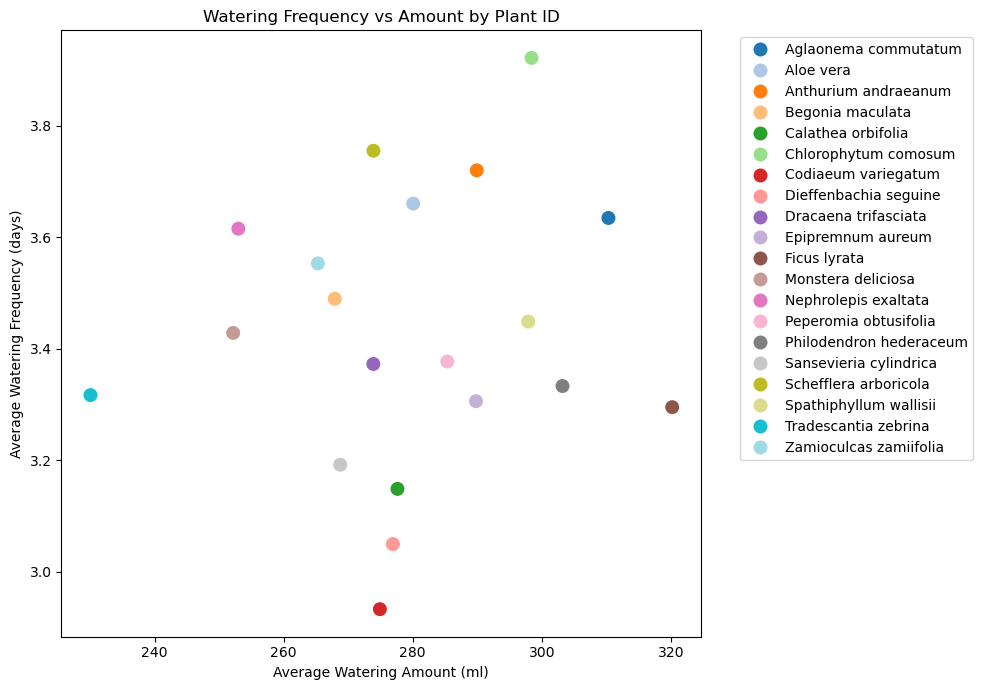

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=plant_water_summary["Watering_Amount_ml"],
    y=plant_water_summary["Watering_Frequency_days"],
    hue=plant_water_summary["Plant_ID"],
    palette="tab20",
    s=120,
    legend="full"
)

plt.title("Watering Frequency vs Amount by Plant ID")
plt.xlabel("Average Watering Amount (ml)")
plt.ylabel("Average Watering Frequency (days)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



### Visualize Watering Behavior

To visually inspect the watering patterns, we'll create scatter plots of watering frequency versus amount. The first plot will show the average for each plant, which helps in seeing the overall behavior of each plant type. The second plot will show all individual watering records, giving a more detailed view of the variability within each plant's watering history. These visualizations will help us understand if there are natural groupings of plants based on their watering needs.

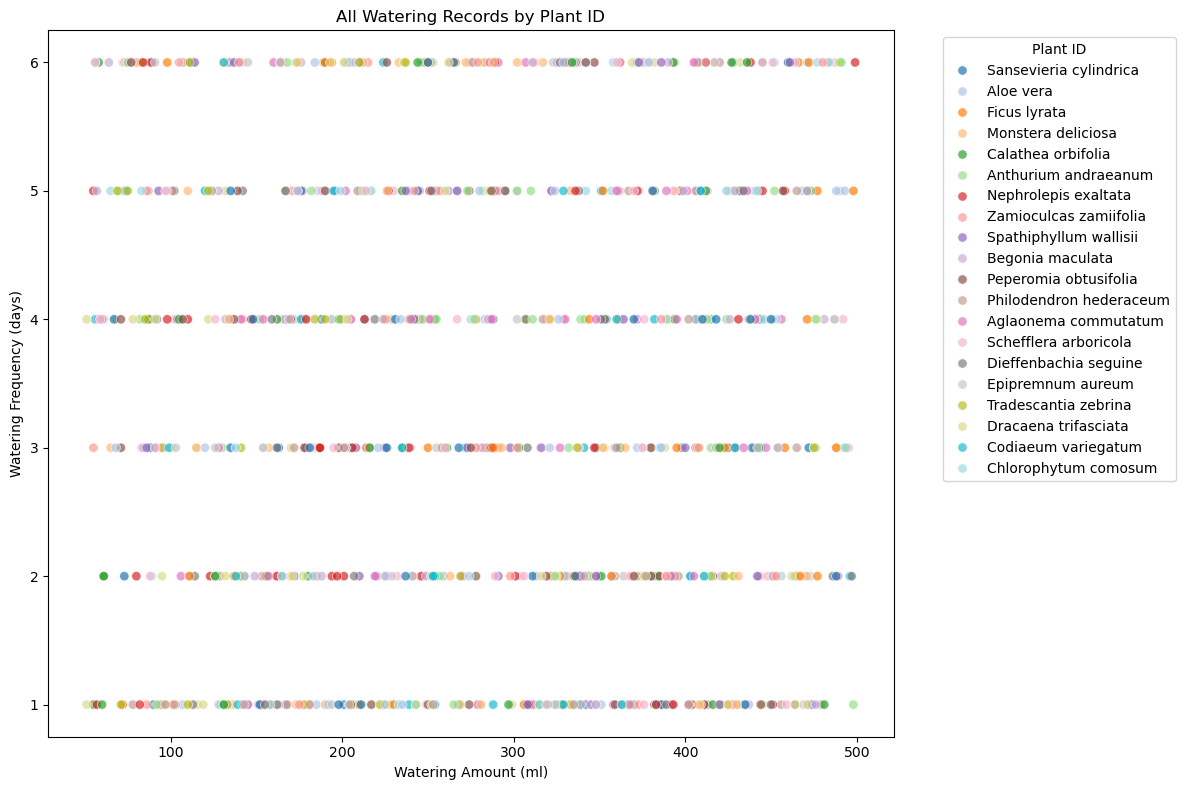

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_clean,
    x="Watering_Amount_ml",
    y="Watering_Frequency_days",
    hue="Plant_ID",
    palette="tab20",
    alpha=0.7,
    s=45
)

plt.title("All Watering Records by Plant ID")
plt.xlabel("Watering Amount (ml)")
plt.ylabel("Watering Frequency (days)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Plant ID")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.cluster import KMeans
import pandas as pd

for k in range(3, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(plant_water_scaled)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print()

c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 3
0     5
1    10
2     5
Name: count, dtype: int64



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 4
0    4
1    6
2    5
3    5
Name: count, dtype: int64



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 5
0    5
1    5
2    5
3    1
4    4
Name: count, dtype: int64



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 6
0    4
1    5
2    1
3    5
4    1
5    4
Name: count, dtype: int64



### Determine the Optimal Number of Clusters (k)

To find the best number of clusters for our watering behavior groups, we'll use the K-Means algorithm and evaluate different values of 'k' (the number of clusters). For each 'k', we'll look at the size of the resulting clusters. A good 'k' should result in clusters that are relatively balanced in size. This is a simple but effective way to get a first idea of a suitable 'k'.

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plant_water_summary = df_clean.groupby("Plant_ID").agg({
    "Watering_Amount_ml": "mean",
    "Watering_Frequency_days": "mean"
}).reset_index()

cluster_features = ["Watering_Amount_ml", "Watering_Frequency_days"]

scaler = StandardScaler()
plant_water_scaled = scaler.fit_transform(plant_water_summary[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
plant_water_summary["Water_Group"] = kmeans.fit_predict(plant_water_scaled)

print(plant_water_summary)

c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


                   Plant_ID  Watering_Amount_ml  Watering_Frequency_days  \
0      Aglaonema commutatum          310.326923                 3.634615   
1                 Aloe vera          280.075472                 3.660377   
2      Anthurium andraeanum          289.920000                 3.720000   
3          Begonia maculata          267.918367                 3.489796   
4        Calathea orbifolia          277.638298                 3.148936   
5      Chlorophytum comosum          298.411765                 3.921569   
6       Codiaeum variegatum          274.911111                 2.933333   
7     Dieffenbachia seguine          276.925000                 3.050000   
8      Dracaena trifasciata          273.898305                 3.372881   
9         Epipremnum aureum          289.795918                 3.306122   
10             Ficus lyrata          320.204545                 3.295455   
11       Monstera deliciosa          252.178571                 3.428571   
12     Nephr

### Apply K-Means Clustering with k=4

Based on the previous analysis, k=4 appears to be a good choice for the number of clusters. We will now apply the K-Means algorithm with k=4 to the scaled watering data. The resulting cluster labels will be added as a new `Water_Group` column to our summary DataFrame. This will be our new engineered feature representing watering behavior profiles.

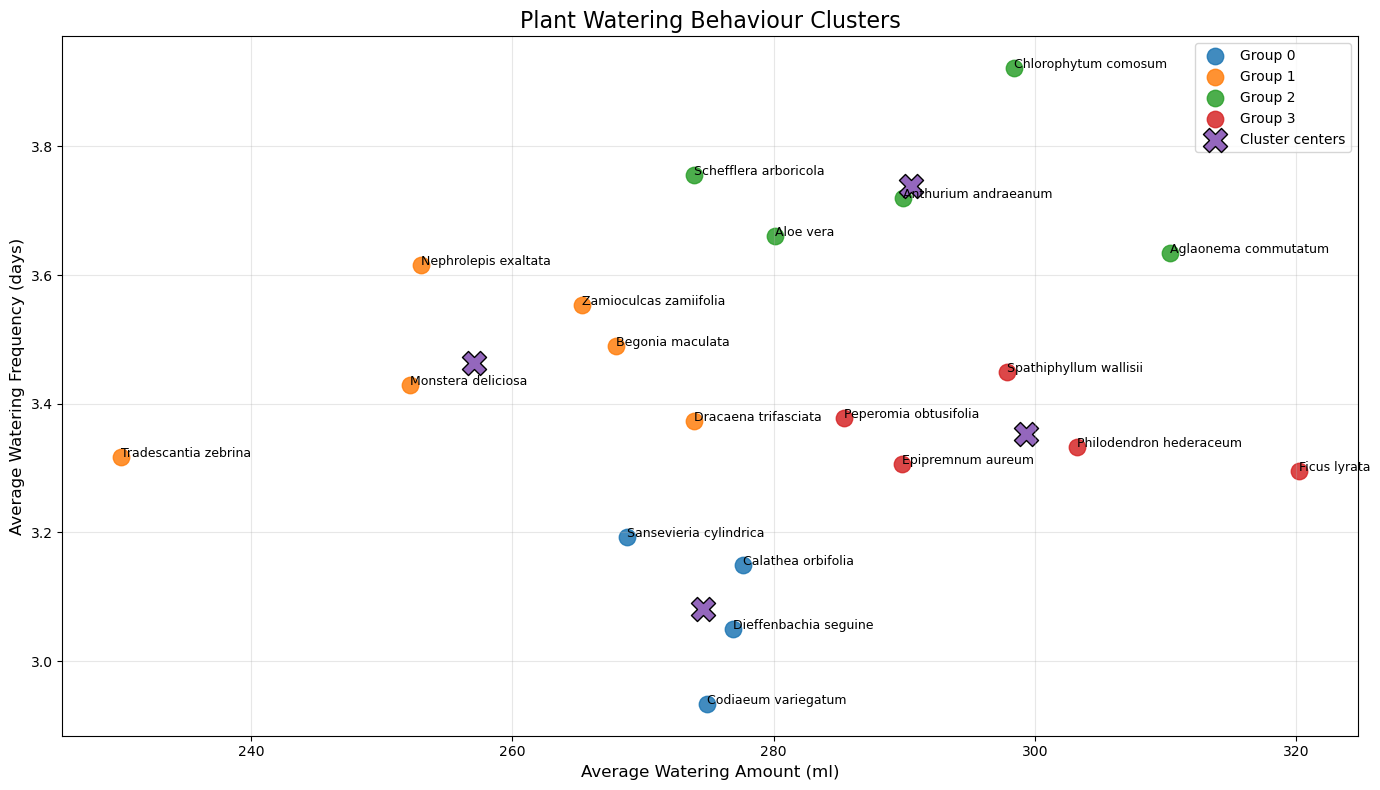

In [23]:
import matplotlib.pyplot as plt

plant_water_summary["Short_Name"] = plant_water_summary["Plant_ID"].apply(
    lambda name: " ".join(name.split()[:2])
)

plt.figure(figsize=(14, 8))
texts = []

for group in sorted(plant_water_summary["Water_Group"].unique()):
    group_data = plant_water_summary[plant_water_summary["Water_Group"] == group]

    plt.scatter(
        group_data["Watering_Amount_ml"],
        group_data["Watering_Frequency_days"],
        label=f"Group {group}",
        s=140,
        alpha=0.85
    )

    for _, row in group_data.iterrows():
        texts.append(
            plt.text(
                row["Watering_Amount_ml"],
                row["Watering_Frequency_days"],
                row["Short_Name"],
                fontsize=9
            )
        )

centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=300,
    label="Cluster centers",
    edgecolors="black"
)



plt.xlabel("Average Watering Amount (ml)", fontsize=12)
plt.ylabel("Average Watering Frequency (days)", fontsize=12)
plt.title("Plant Watering Behaviour Clusters", fontsize=16)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Visualize the Clustered Watering Groups

To better understand the results of our clustering, we will create a scatter plot of the plant watering data, with each point colored according to its assigned `Water_Group`. We'll also plot the cluster centers. This visualization will help us to see how well the clusters separate the plants and to interpret the characteristics of each group (e.g., high frequency/low amount vs. low frequency/high amount).

In [24]:
water_group_mapping = plant_water_summary[["Plant_ID", "Water_Group"]]

df_clean = df_clean.merge(
    water_group_mapping,
    on="Plant_ID",
    how="left"
)

print(df_clean[["Plant_ID", "Water_Group"]].head(20))
print(df_clean["Water_Group"].value_counts().sort_index())

                   Plant_ID  Water_Group
0    Sansevieria cylindrica            0
1                 Aloe vera            2
2              Ficus lyrata            3
3        Monstera deliciosa            1
4              Ficus lyrata            3
5              Ficus lyrata            3
6        Calathea orbifolia            0
7      Anthurium andraeanum            2
8              Ficus lyrata            3
9      Anthurium andraeanum            2
10     Nephrolepis exaltata            1
11   Zamioculcas zamiifolia            1
12       Monstera deliciosa            1
13   Spathiphyllum wallisii            3
14   Zamioculcas zamiifolia            1
15         Begonia maculata            1
16    Peperomia obtusifolia            3
17       Monstera deliciosa            1
18  Philodendron hederaceum            3
19     Aglaonema commutatum            2
Water_Group
0    184
1    304
2    255
3    249
Name: count, dtype: int64


### Merge the `Water_Group` into the Main DataFrame

Now that we have created the `Water_Group` for each `Plant_ID`, we need to add this information back into our main cleaned DataFrame. We will perform a merge (similar to a SQL join) to add the `Water_Group` column based on the `Plant_ID`. This will make the new feature available for every row in our dataset. We'll then check the distribution of the new feature and verify that the merge was successful.

In [25]:
print("Missing Water_Group:", df_clean["Water_Group"].isnull().sum())

Missing Water_Group: 0


In [26]:
df_model = df_clean.drop(columns=["Plant_ID"])
df_model

,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Health_Score,Light,Soil_Chalky,Soil_Clay,Soil_Loamy,Soil_Peaty,Soil_Sandy,Soil_Silty,Water_Group
0,17.39,17,8,205,3,21.7,77.5,51.9,1,622,0,1,0,0,0,0,0
1,9.84,31,9,191,1,22.6,68.9,28.2,2,794,0,0,1,0,0,0,2
2,19.82,40,8,477,5,17.2,44.3,13.6,1,514,0,0,0,0,1,0,3
3,37.08,11,1,207,1,25.0,72.2,38.4,4,88,0,0,0,0,1,0,1
4,2.96,26,3,465,2,23.2,51.6,37.9,1,308,0,0,0,1,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,32.27,16,7,370,4,32.4,58.0,31.7,3,870,0,0,0,0,1,0,0
988,26.60,44,0,91,3,24.3,39.4,32.9,4,261,0,0,0,0,0,1,2
989,9.69,13,0,134,4,26.4,52.4,58.5,5,797,0,0,0,1,0,0,1
990,23.54,16,7,442,3,18.7,60.1,24.8,2,686,0,0,1,0,0,0,3


### Prepare the Final DataFrame for Modeling

With the feature engineering complete, we will now prepare the final DataFrame for modeling. This involves dropping the `Plant_ID` column, as it has been replaced by the `Water_Group` feature. The resulting `df_model` DataFrame will contain only the features to be used in the machine learning model. We'll do a final check of the data types and for any remaining missing values.

In [27]:
print(df_model.info())
print(df_model.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Height_cm                992 non-null    float64
 1   Leaf_Count               992 non-null    int64  
 2   New_Growth_Count         992 non-null    int64  
 3   Watering_Amount_ml       992 non-null    int64  
 4   Watering_Frequency_days  992 non-null    int64  
 5   Room_Temperature_C       992 non-null    float64
 6   Humidity_%               992 non-null    float64
 7   Soil_Moisture_%          992 non-null    float64
 8   Health_Score             992 non-null    int64  
 9   Light                    992 non-null    int64  
 10  Soil_Chalky              992 non-null    int32  
 11  Soil_Clay                992 non-null    int32  
 12  Soil_Loamy               992 non-null    int32  
 13  Soil_Peaty               992 non-null    int32  
 14  Soil_Sandy               9

In [28]:
print(df_model.describe())

        Height_cm  Leaf_Count  New_Growth_Count  Watering_Amount_ml  \
count  992.000000  992.000000        992.000000          992.000000   
mean    25.947429   27.042339          4.516129          279.678427   
std     10.186447   12.767194          2.848290          124.702829   
min      0.480000    5.000000          0.000000           51.000000   
25%     19.197500   16.000000          2.000000          175.750000   
50%     26.070000   26.000000          5.000000          279.000000   
75%     32.690000   38.000000          7.000000          389.000000   
max     57.600000   49.000000          9.000000          499.000000   

       Watering_Frequency_days  Room_Temperature_C  Humidity_%  \
count               992.000000          992.000000  992.000000   
mean                  3.436492           23.950907   54.716734   
std                   1.751459            3.168924   14.422219   
min                   1.000000           14.300000   30.000000   
25%                   2.000000

In [29]:
print(df_model["Water_Group"].value_counts().sort_index())
print(df_model["Water_Group"].unique())

Water_Group
0    184
1    304
2    255
3    249
Name: count, dtype: int64
[0 2 3 1]


In [30]:
correlations = df_model.corr(numeric_only=True)["Watering_Amount_ml"].sort_values(ascending=False)
print(correlations)

Watering_Amount_ml         1.000000
Water_Group                0.101554
Height_cm                  0.059931
Soil_Moisture_%            0.032227
Soil_Loamy                 0.029085
Soil_Clay                  0.017002
Soil_Sandy                 0.016022
Light                      0.007971
New_Growth_Count           0.002425
Room_Temperature_C        -0.003986
Watering_Frequency_days   -0.009844
Soil_Chalky               -0.010233
Humidity_%                -0.010803
Leaf_Count                -0.014540
Health_Score              -0.023471
Soil_Peaty                -0.025278
Soil_Silty                -0.026449
Name: Watering_Amount_ml, dtype: float64


In [31]:
print("Duplicate rows:", df_model.duplicated().sum())

Duplicate rows: 0


In [32]:
# df_clean[Plant_ID] one hot encoding
df_clean.drop

<bound method DataFrame.drop of                    Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
0    Sansevieria cylindrica      17.39          17                 8   
1                 Aloe vera       9.84          31                 9   
2              Ficus lyrata      19.82          40                 8   
3        Monstera deliciosa      37.08          11                 1   
4              Ficus lyrata       2.96          26                 3   
..                      ...        ...         ...               ...   
987  Sansevieria cylindrica      32.27          16                 7   
988   Schefflera arboricola      26.60          44                 0   
989      Monstera deliciosa       9.69          13                 0   
990       Epipremnum aureum      23.54          16                 7   
991  Sansevieria cylindrica      37.90          30                 4   

     Watering_Amount_ml  Watering_Frequency_days  Room_Temperature_C  \
0                   205        

### Alternative Clustering Approach: Full Feature Set

As an alternative to clustering only on watering behavior, we will now try clustering on a broader set of features. This will help us to see if there are more general plant profiles that go beyond just watering. We will use features like soil moisture, light, temperature, and humidity in addition to the watering features. This is an exploratory step to see if a more complex clustering approach yields better-defined groups.

In [33]:
df_clean = df_clean.drop(columns=["Water_Group"])

plant_profile = df_clean.groupby("Plant_ID").agg({
    "Watering_Amount_ml": "mean",
    "Watering_Frequency_days": "mean",
    "Soil_Moisture_%": "mean",
    "Light": "mean",
    "Room_Temperature_C": "mean",
    "Humidity_%": "mean",
    "Health_Score": "mean"
}).reset_index()

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

profile_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

scaler = StandardScaler()
plant_profile_scaled = scaler.fit_transform(plant_profile[profile_features])

pca = PCA(n_components=2)
plant_profile_pca = pca.fit_transform(plant_profile_scaled)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())

Explained variance: [0.27817754 0.21850319]
Total explained: 0.49668073536316537


### Evaluate Clustering with Elbow Method and Silhouette Score

To find the optimal number of clusters for this new full-feature approach, we will use two common evaluation methods: the Elbow Method and the Silhouette Score. The Elbow Method looks for a "k" where the inertia (within-cluster sum of squares) starts to decrease less rapidly. The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters. We will calculate these metrics for a range of 'k' values.

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(plant_profile_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(plant_profile_scaled, labels))

    print("k =", k)
    print("Cluster sizes:")
    print(pd.Series(labels).value_counts().sort_index())
    print("Silhouette:", silhouette_score(plant_profile_scaled, labels))
    print()

c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 2
Cluster sizes:
0    12
1     8
Name: count, dtype: int64
Silhouette: 0.1470512609261275



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 3
Cluster sizes:
0     8
1    10
2     2
Name: count, dtype: int64
Silhouette: 0.13617862897521335



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

k = 6
Cluster sizes:
0    4
1    3
2    8
3    1
4    2
5    2
Name: count, dtype: int64
Silhouette: 0.12337030133149936



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 7
Cluster sizes:
0    1
1    7
2    1
3    2
4    6
5    1
6    2
Name: count, dtype: int64
Silhouette: 0.10474278122125753



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 8
Cluster sizes:
0    1
1    5
2    4
3    5
4    2
5    1
6    1
7    1
Name: count, dtype: int64
Silhouette: 0.1035711506079362



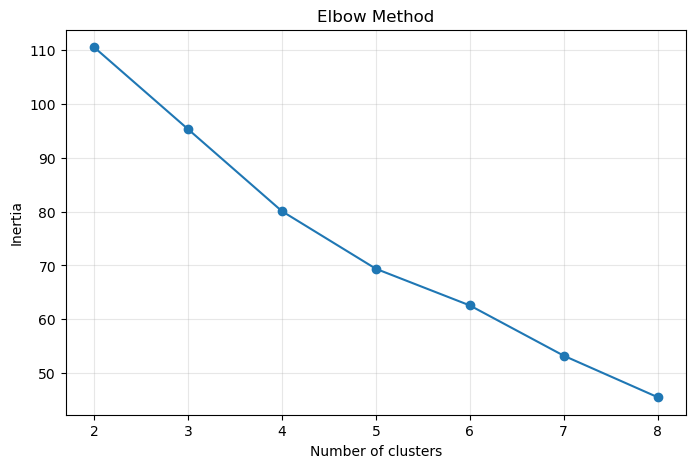

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True, alpha=0.3)
plt.show()

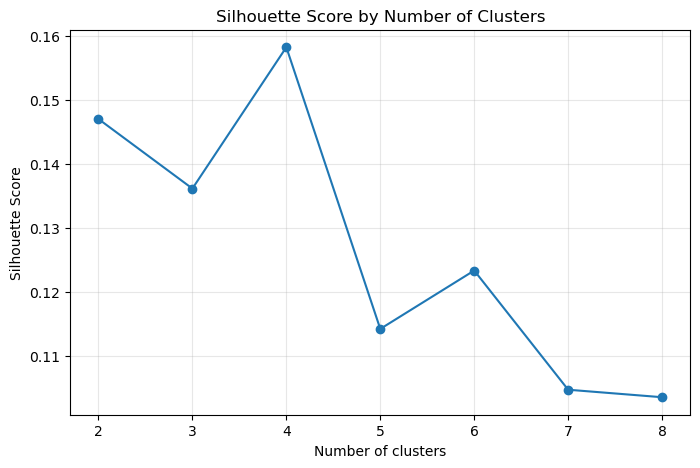

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

profile_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

scaler = StandardScaler()
plant_profile_scaled = scaler.fit_transform(plant_profile[profile_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
plant_profile["Water_Group"] = kmeans.fit_predict(plant_profile_scaled)

print("Cluster sizes:")
print(plant_profile["Water_Group"].value_counts().sort_index())

print("Silhouette:")
print(silhouette_score(plant_profile_scaled, plant_profile["Water_Group"]))

pca = PCA(n_components=2)
plant_profile_pca = pca.fit_transform(plant_profile_scaled)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())

plant_profile["PC1"] = plant_profile_pca[:, 0]
plant_profile["PC2"] = plant_profile_pca[:, 1]

c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster sizes:
Water_Group
0    3
1    7
2    7
3    3
Name: count, dtype: int64
Silhouette:
0.15826871692589328
Explained variance: [0.27817754 0.21850319]
Total explained: 0.49668073536316537


### Apply and Visualize Full-Feature Clustering with PCA

Based on the evaluation, we will choose the best 'k' and apply K-Means clustering to the full feature set. To visualize the results of this high-dimensional clustering, we will use Principal Component Analysis (PCA) to reduce the data to two dimensions. This allows us to create a scatter plot where we can see the clusters in a 2D space, which helps in interpreting the separation between the groups.

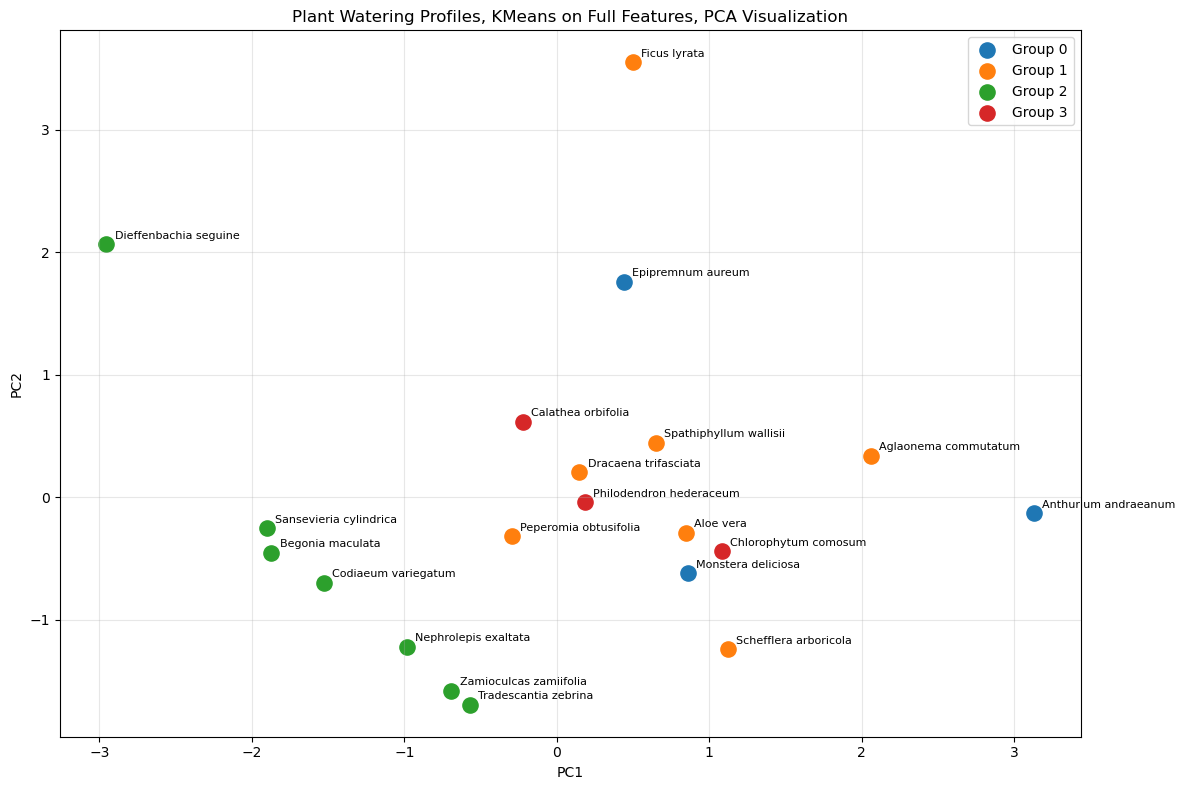

In [39]:
plt.figure(figsize=(12, 8))

for group in sorted(plant_profile["Water_Group"].unique()):
    group_data = plant_profile[plant_profile["Water_Group"] == group]

    plt.scatter(
        group_data["PC1"],
        group_data["PC2"],
        label=f"Group {group}",
        s=120
    )

    for _, row in group_data.iterrows():
        plt.annotate(
            row["Plant_ID"],
            (row["PC1"], row["PC2"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Plant Watering Profiles, KMeans on Full Features, PCA Visualization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KMeans on 7-dimensional scaled features
→ then projected down to 2D with PCA for visualization

The clusters exist, but they are only weakly separated
bc silhouette score was only: 0.158

In [40]:
plant_profile.groupby("Water_Group")[[
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]].mean()

,Watering_Amount_ml,Watering_Frequency_days,Soil_Moisture_%,Light,Room_Temperature_C,Humidity_%,Health_Score
Water_Group,,,,,,,
0,277.298163,3.484898,33.273041,437.749422,23.875422,53.703939,2.787585
1,291.668580,3.506396,33.171800,547.232089,23.656312,54.403679,3.053524
2,262.410789,3.307298,35.468893,528.560544,24.228399,56.030629,3.191153
3,293.084589,3.467946,38.058188,511.044230,24.071926,53.711749,2.884779


### Analyze Cluster Characteristics

After clustering, it's important to understand what defines each cluster. We will calculate the mean of each feature for each `Water_Group`. This will give us a profile for each cluster, showing, for example, that one group is characterized by high light and low humidity, while another might have low temperature and high soil moisture. This step is key to giving a meaningful interpretation to the clusters we have created.

In [41]:
profile_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

print(plant_profile[profile_features].skew().sort_values(ascending=False))

Soil_Moisture_%            0.519574
Humidity_%                 0.442187
Watering_Frequency_days   -0.020165
Watering_Amount_ml        -0.245385
Health_Score              -0.546421
Light                     -0.662784
Room_Temperature_C        -1.317619
dtype: float64


### Check for Skewness in Features

The low silhouette score in the previous clustering attempt suggests that the clusters are not well-separated. One possible reason is that some of the features are skewed. Skewed data can negatively impact the performance of distance-based algorithms like K-Means. We will now check the skewness of our features and visualize their distributions using histograms. This will help us decide if a transformation is needed to make the data more suitable for clustering.

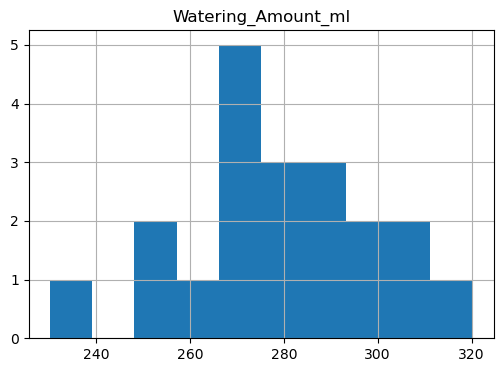

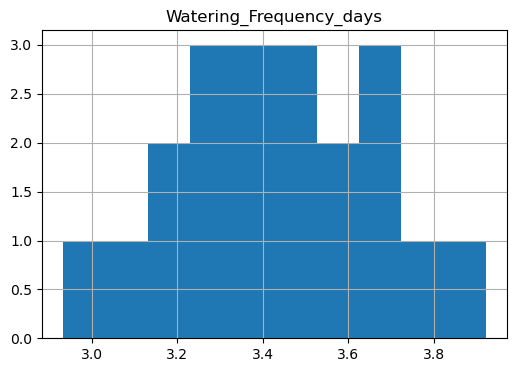

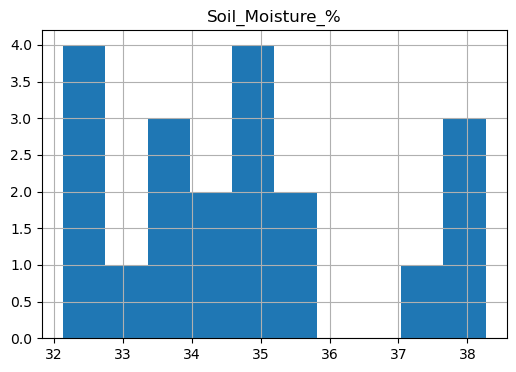

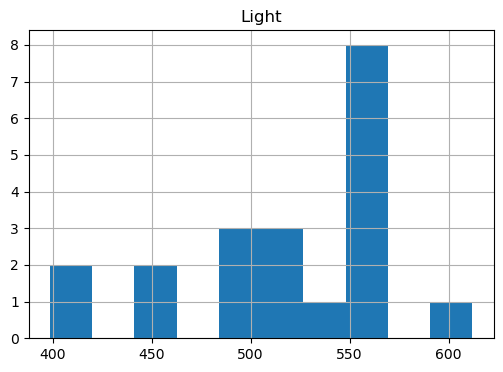

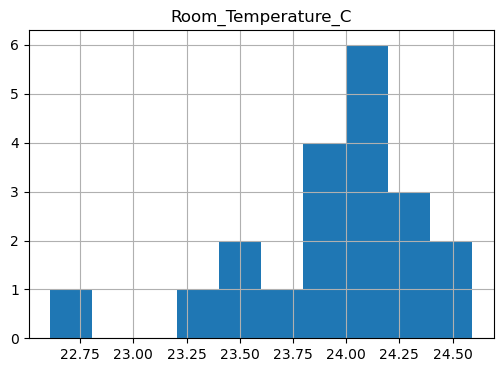

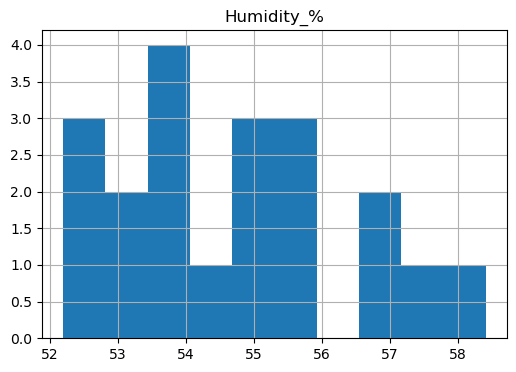

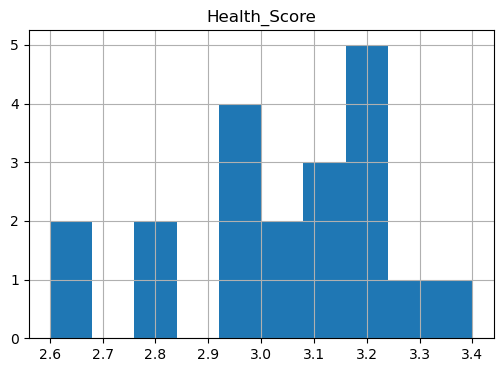

In [42]:
import matplotlib.pyplot as plt

for col in profile_features:
    plt.figure(figsize=(6, 4))
    plant_profile[col].hist(bins=10)
    plt.title(col)
    plt.show()

In [43]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

profile_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

transform_pipeline = Pipeline([
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

plant_profile_transformed = transform_pipeline.fit_transform(
    plant_profile[profile_features]
)

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(plant_profile_transformed)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print("Silhouette:", silhouette_score(plant_profile_transformed, labels))
    print()

c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 2
0    12
1     8
Name: count, dtype: int64
Silhouette: 0.15912133946129967



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 3
0    8
1    5
2    7
Name: count, dtype: int64
Silhouette: 0.14456214720322705



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

k = 6
0    2
1    2
2    3
3    6
4    6
5    1
Name: count, dtype: int64
Silhouette: 0.11039395547254376



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 7
0    2
1    6
2    2
3    3
4    4
5    1
6    2
Name: count, dtype: int64
Silhouette: 0.107567222364185



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 8
0    5
1    5
2    2
3    1
4    1
5    2
6    1
7    3
Name: count, dtype: int64
Silhouette: 0.11533395395183454



### Apply Power Transformation to Reduce Skewness

Since some features were found to be skewed, we will now apply a power transformation (specifically, the Yeo-Johnson transformation) to make their distributions more symmetric and closer to a normal distribution. This can often improve the performance of clustering algorithms. We will then re-run the K-Means clustering on the transformed data and re-evaluate the silhouette scores to see if this approach yields better-defined clusters.

### Cluster only on the real watering behaviour

### Re-focus on Watering Behavior Clustering

The previous attempts to cluster on the full feature set, even with transformations, did not produce well-separated clusters. This suggests that the most distinct patterns in the data are related to watering behavior. Therefore, we will go back to our initial, more successful approach of clustering only on the `Watering_Amount_ml` and `Watering_Frequency_days` features. This time, we will more formally evaluate the number of clusters using the silhouette score.

In [44]:
features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days"
]

X = plant_profile[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print("Silhouette:", silhouette_score(X_scaled, labels))
    print()

c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 2
0    10
1    10
Name: count, dtype: int64
Silhouette: 0.30505294182067166



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 3
0     5
1    10
2     5
Name: count, dtype: int64
Silhouette: 0.3544160224258025



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 4
0    4
1    6
2    5
3    5
Name: count, dtype: int64
Silhouette: 0.4064425248057857



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 5
0    5
1    5
2    5
3    1
4    4
Name: count, dtype: int64
Silhouette: 0.3886405243301521



c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k = 6
0    4
1    5
2    1
3    5
4    1
5    4
Name: count, dtype: int64
Silhouette: 0.33108285416652306



### Alternative Clustering Algorithm: Hierarchical Clustering

To explore other clustering possibilities, we will now try a different algorithm: Agglomerative Hierarchical Clustering. This method builds a hierarchy of clusters, which can be visualized as a dendrogram. It doesn't require specifying the number of clusters beforehand, and the dendrogram can help in choosing a suitable number of clusters by identifying where the merges happen at large distances. We will also evaluate the results using the silhouette score.

In [45]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

X_scaled = StandardScaler().fit_transform(plant_profile[features])

for k in range(2, 7):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_scaled)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print("Silhouette:", silhouette_score(X_scaled, labels))
    print()

k = 2
0    18
1     2
Name: count, dtype: int64
Silhouette: 0.23687032404837494

k = 3
0    9
1    2
2    9
Name: count, dtype: int64
Silhouette: 0.10271768939394685

k = 4
0    9
1    2
2    5
3    4
Name: count, dtype: int64
Silhouette: 0.0996474872742068

k = 5
0    4
1    2
2    5
3    4
4    5
Name: count, dtype: int64
Silhouette: 0.11140180916572928

k = 6
0    2
1    2
2    5
3    4
4    5
5    2
Name: count, dtype: int64
Silhouette: 0.1343932386567597



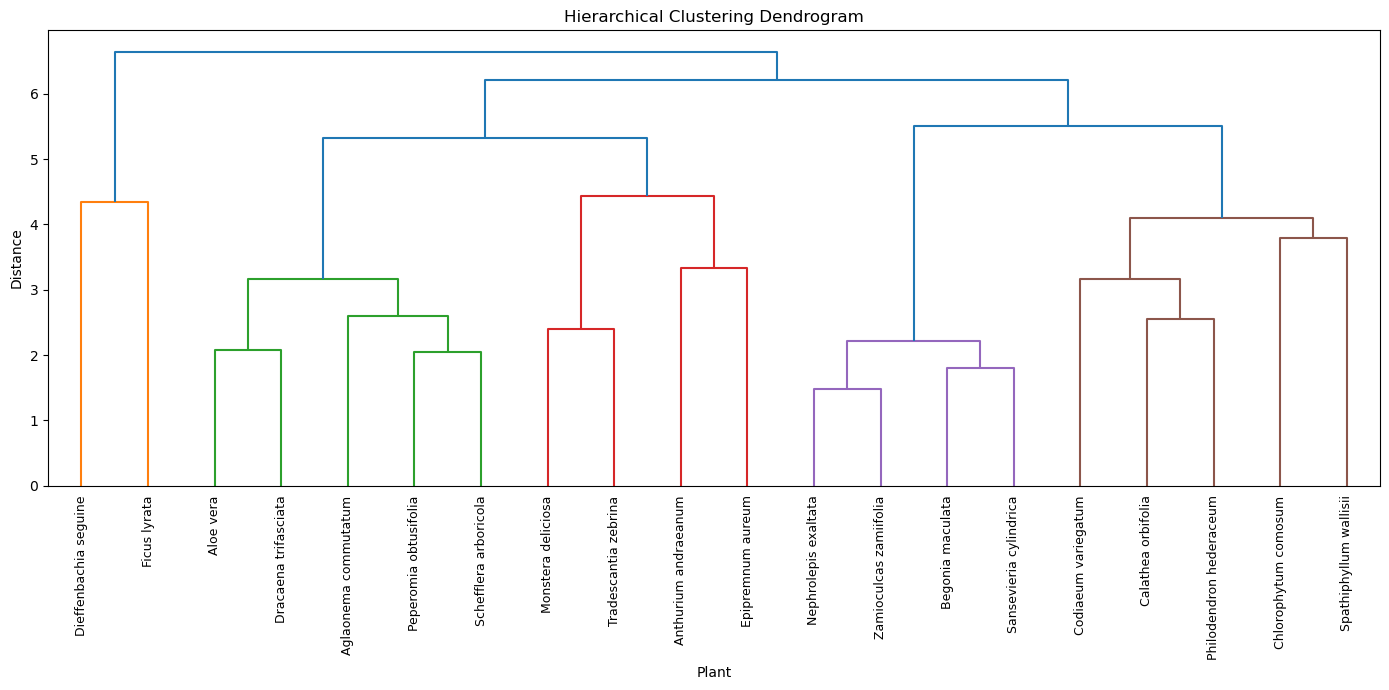

In [46]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

X_scaled = StandardScaler().fit_transform(plant_profile[features])

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    labels=plant_profile["Plant_ID"].values,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Plant")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Visualize Hierarchical Clustering with a Dendrogram

A key advantage of hierarchical clustering is the dendrogram, which provides a rich visualization of the cluster hierarchy. We will now create a dendrogram to see how the plants are grouped at different levels of similarity. This can provide insights into the relationships between different plants and help in deciding on a final number of clusters by looking for a level to "cut" the dendrogram that results in a sensible grouping.

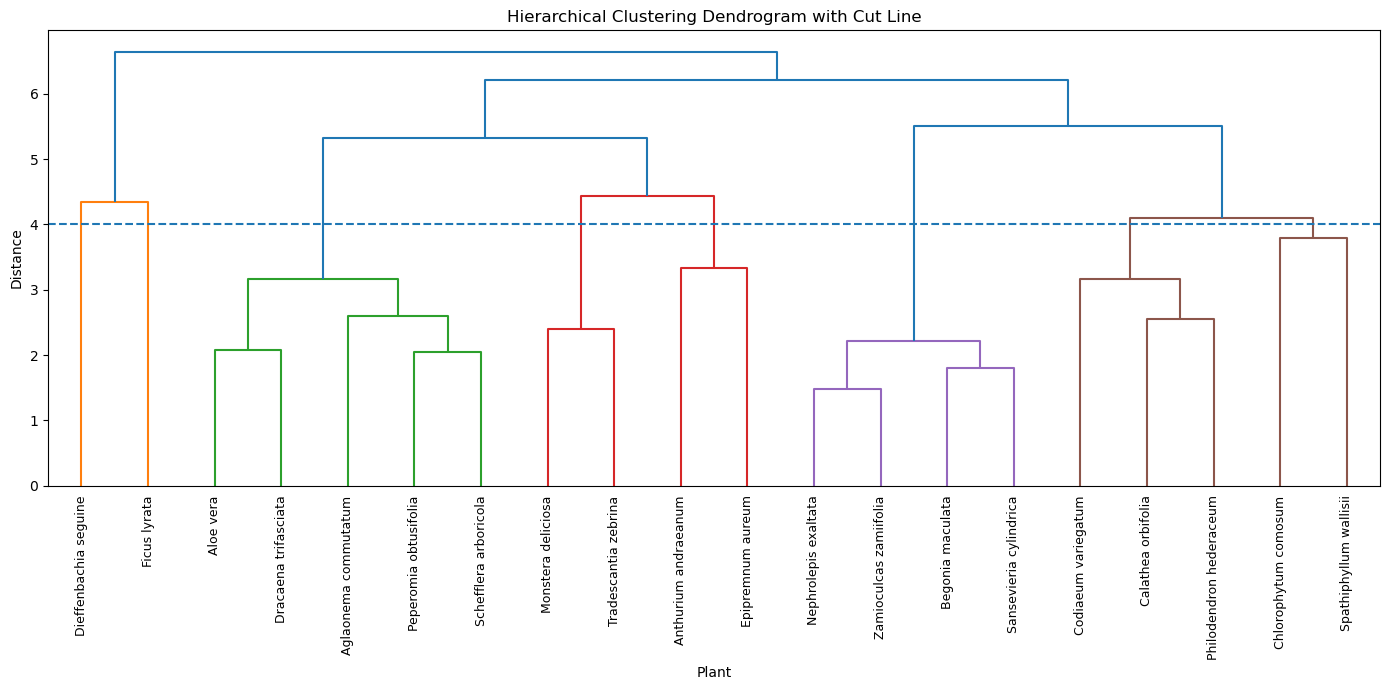

In [47]:
plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    labels=plant_profile["Plant_ID"].values,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.axhline(y=4, linestyle="--")

plt.title("Hierarchical Clustering Dendrogram with Cut Line")
plt.xlabel("Plant")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Alternative Clustering Algorithm: DBSCAN

We will now experiment with another clustering algorithm, DBSCAN (Density-Based Spatial Clustering of Applications with Noise). Unlike K-Means, DBSCAN does not require the number of clusters to be specified. Instead, it groups together points that are closely packed together, marking as outliers points that lie alone in low-density regions. This is useful for discovering clusters of arbitrary shape and for identifying noise in the data. We will try different values for the `eps` parameter, which defines the neighborhood around a point.

In [48]:
from sklearn.cluster import DBSCAN

for eps in [0.8, 1.0, 1.2, 1.5, 2.0]:
    model = DBSCAN(eps=eps, min_samples=2)
    labels = model.fit_predict(X_scaled)

    print("eps =", eps)
    print(pd.Series(labels).value_counts().sort_index())
    print()

eps = 0.8
-1    20
Name: count, dtype: int64

eps = 1.0
-1    20
Name: count, dtype: int64

eps = 1.2
-1    20
Name: count, dtype: int64

eps = 1.5
-1    18
 0     2
Name: count, dtype: int64

eps = 2.0
-1    16
 0     4
Name: count, dtype: int64



### Clustering on Full Rows Instead of Plant Averages

So far, we have been clustering on data that was aggregated to the plant level. Now, we will try a different approach: clustering on the full, unaggregated data. This means that each row in our dataset will be treated as a separate data point. This could potentially reveal different patterns that are not visible when we average the data for each plant. We will again use K-Means and evaluate with the silhouette score.

In [49]:
features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

X_scaled = StandardScaler().fit_transform(df_model[features])

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print("Silhouette:", silhouette_score(X_scaled, labels))
    print()

k = 2
0    480
1    512
Name: count, dtype: int64
Silhouette: 0.11224326607397059

k = 3
0    310
1    350
2    332
Name: count, dtype: int64
Silhouette: 0.10484623811797832

k = 4
0    259
1    233
2    269
3    231
Name: count, dtype: int64
Silhouette: 0.10527864058603008

k = 5
0    208
1    210
2    197
3    192
4    185
Name: count, dtype: int64
Silhouette: 0.10898036386767457

k = 6
0    162
1    168
2    156
3    161
4    157
5    188
Name: count, dtype: int64
Silhouette: 0.11464221719225477

k = 7
0    152
1    158
2    145
3    138
4    131
5    125
6    143
Name: count, dtype: int64
Silhouette: 0.11549109822532129

k = 8
0    120
1    106
2    128
3    128
4    124
5    127
6    145
7    114
Name: count, dtype: int64
Silhouette: 0.12045477451201961



### Alternative to Clustering: Binning `Watering_Amount_ml`

As an alternative to the complexity of clustering, we can use a simpler method to categorize the watering behavior: binning. We will create a new categorical feature, `Watering_Category`, by dividing the `Watering_Amount_ml` into a few predefined bins (e.g., "low", "medium", "high"). This is a straightforward way to convert a continuous variable into a categorical one, which can sometimes be sufficient for the modeling needs and is easier to interpret than clusters.

In [50]:
df_model["Watering_Category"] = pd.cut(
    df_model["Watering_Amount_ml"],
    bins=[0, 180, 350, 500],
    labels=["low", "medium", "high"]
)

print(df_model["Watering_Category"].value_counts())

Watering_Category
medium    392
high      338
low       262
Name: count, dtype: int64


### Final Clustering Model Selection and Application

After extensive experimentation with different clustering methods, feature sets, and data transformations, we have concluded that the most meaningful and well-separated clusters are obtained by applying K-Means with k=4 to the two main watering behavior features: `Watering_Amount_ml` and `Watering_Frequency_days`. This approach yielded the best silhouette score. We will now finalize this choice, apply the clustering, and analyze the resulting groups to define our plant watering profiles for the prototype.

In [51]:
water_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days"
]

plant_water_summary = df_clean.groupby("Plant_ID")[water_features].mean().reset_index()

scaler = StandardScaler()
plant_water_scaled = scaler.fit_transform(plant_water_summary[water_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
plant_water_summary["Water_Group"] = kmeans.fit_predict(plant_water_scaled)

print(
    plant_water_summary
    .sort_values(["Water_Group", "Watering_Amount_ml", "Watering_Frequency_days"])
)

c:\Users\youss\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


                   Plant_ID  Watering_Amount_ml  Watering_Frequency_days  \
15   Sansevieria cylindrica          268.769231                 3.192308   
6       Codiaeum variegatum          274.911111                 2.933333   
7     Dieffenbachia seguine          276.925000                 3.050000   
4        Calathea orbifolia          277.638298                 3.148936   
18     Tradescantia zebrina          230.073171                 3.317073   
11       Monstera deliciosa          252.178571                 3.428571   
12     Nephrolepis exaltata          252.980769                 3.615385   
19   Zamioculcas zamiifolia          265.297872                 3.553191   
3          Begonia maculata          267.918367                 3.489796   
8      Dracaena trifasciata          273.898305                 3.372881   
16    Schefflera arboricola          273.918367                 3.755102   
1                 Aloe vera          280.075472                 3.660377   
2      Anthu

In [52]:
print(
    plant_water_summary.groupby("Water_Group")[[
        "Watering_Amount_ml",
        "Watering_Frequency_days"
    ]].mean()
)

             Watering_Amount_ml  Watering_Frequency_days
Water_Group                                             
0                    274.560910                 3.081144
1                    257.057843                 3.462816
2                    290.530505                 3.738333
3                    299.292123                 3.352250


In [53]:
print(
    plant_water_summary.groupby("Water_Group")[[
        "Watering_Amount_ml",
        "Watering_Frequency_days"
    ]].agg(["mean", "min", "max", "count"])
)

            Watering_Amount_ml                                \
                          mean         min         max count   
Water_Group                                                    
0                   274.560910  268.769231  277.638298     4   
1                   257.057843  230.073171  273.898305     6   
2                   290.530505  273.918367  310.326923     5   
3                   299.292123  285.358491  320.204545     5   

            Watering_Frequency_days                            
                               mean       min       max count  
Water_Group                                                    
0                          3.081144  2.933333  3.192308     4  
1                          3.462816  3.317073  3.615385     6  
2                          3.738333  3.634615  3.921569     5  
3                          3.352250  3.295455  3.448980     5  


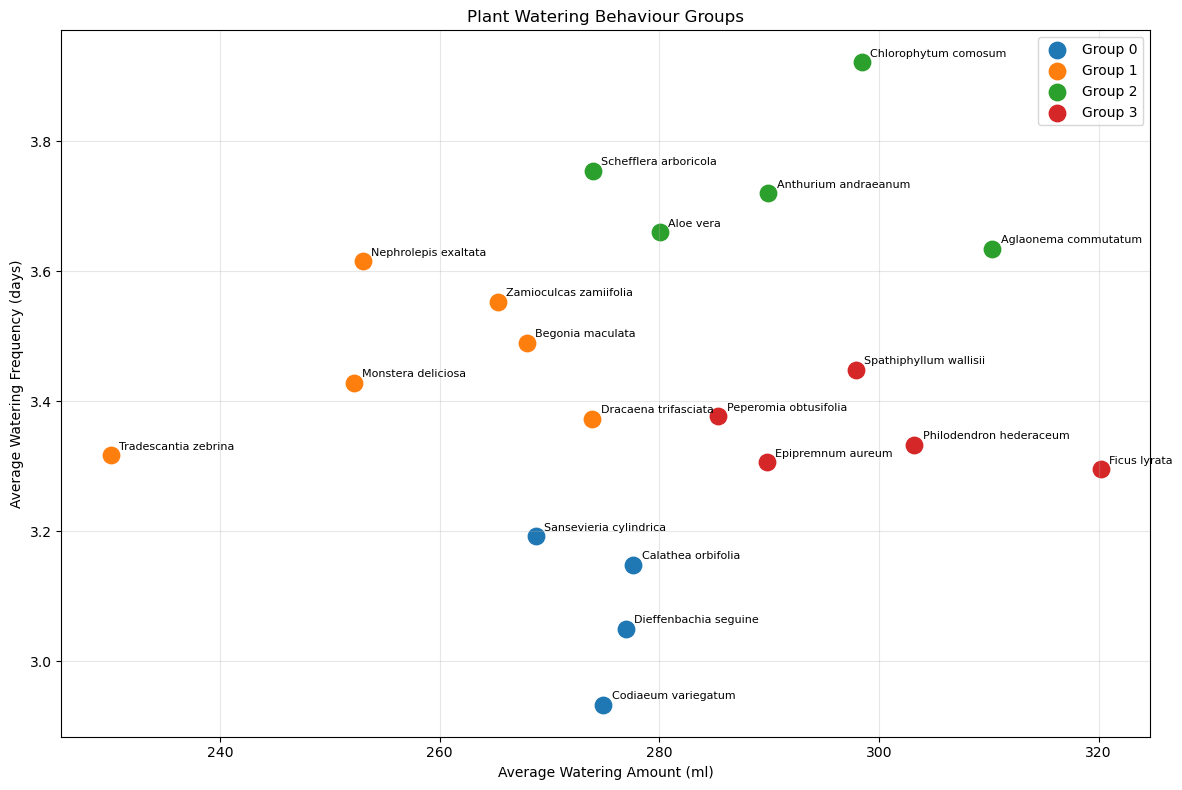

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for group in sorted(plant_water_summary["Water_Group"].unique()):
    group_data = plant_water_summary[plant_water_summary["Water_Group"] == group]

    plt.scatter(
        group_data["Watering_Amount_ml"],
        group_data["Watering_Frequency_days"],
        label=f"Group {group}",
        s=140
    )

    for _, row in group_data.iterrows():
        plt.annotate(
            row["Plant_ID"],
            (row["Watering_Amount_ml"], row["Watering_Frequency_days"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8
        )

plt.xlabel("Average Watering Amount (ml)")
plt.ylabel("Average Watering Frequency (days)")
plt.title("Plant Watering Behaviour Groups")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Final Visualization of Watering Behavior Groups

To conclude our analysis, we will create a final, clean visualization of the chosen watering behavior groups. This scatter plot will clearly show the four groups of plants based on their average watering amount and frequency. Annotating the points with the plant IDs will make it easy to see which plants belong to each group. This visualization serves as a clear summary of our feature engineering work and provides a solid basis for the subsequent modeling steps.

### Model Building: Predicting Watering Amount

Now that we have preprocessed the data and engineered a meaningful `Water_Group` feature, we can proceed to build a regression model to predict the `Watering_Amount_ml`. We will test several different regression algorithms to see which one performs best on our dataset.

### 1. Data Preparation for Modeling

Before we can train any models, we need to prepare the data. This involves:
1.  **Defining Features (X) and Target (y):** We'll separate our dataset into the features that will be used for prediction and the target variable we want to predict, which is `Watering_Amount_ml`.
2.  **Splitting the Data:** We'll split the data into a training set and a testing set. The model will be trained on the training set, and its performance will be evaluated on the unseen testing set. This helps to ensure that our model can generalize to new data.

In [55]:
from sklearn.model_selection import train_test_split

# Merge the water group mapping to the cleaned dataframe
df_model = df_clean.merge(
    plant_water_summary[['Plant_ID', 'Water_Group']],
    on='Plant_ID',
    how='left'
)

# Drop the original Plant_ID as it's now represented by Water_Group
df_model = df_model.drop(columns=['Plant_ID'])

# Define features (X) and target (y)
X = df_model.drop('Watering_Amount_ml', axis=1)
y = df_model['Watering_Amount_ml']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (793, 16)
Testing set shape: (199, 16)


In [60]:
df_model

,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Health_Score,Light,Soil_Chalky,Soil_Clay,Soil_Loamy,Soil_Peaty,Soil_Sandy,Soil_Silty,Water_Group
0,17.39,17,8,205,3,21.7,77.5,51.9,1,622,0,1,0,0,0,0,0
1,9.84,31,9,191,1,22.6,68.9,28.2,2,794,0,0,1,0,0,0,2
2,19.82,40,8,477,5,17.2,44.3,13.6,1,514,0,0,0,0,1,0,3
3,37.08,11,1,207,1,25.0,72.2,38.4,4,88,0,0,0,0,1,0,1
4,2.96,26,3,465,2,23.2,51.6,37.9,1,308,0,0,0,1,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,32.27,16,7,370,4,32.4,58.0,31.7,3,870,0,0,0,0,1,0,0
988,26.60,44,0,91,3,24.3,39.4,32.9,4,261,0,0,0,0,0,1,2
989,9.69,13,0,134,4,26.4,52.4,58.5,5,797,0,0,0,1,0,0,1
990,23.54,16,7,442,3,18.7,60.1,24.8,2,686,0,0,1,0,0,0,3


In [61]:
# one hot encoding for Water_Group
df_model = pd.get_dummies(df_model, columns=['Water_Group'], prefix='Water_Group', dtype=int)
df_model.head()

,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Health_Score,Light,Soil_Chalky,Soil_Clay,Soil_Loamy,Soil_Peaty,Soil_Sandy,Soil_Silty,Water_Group_0,Water_Group_1,Water_Group_2,Water_Group_3
0,17.39,17,8,205,3,21.7,77.5,51.9,1,622,0,1,0,0,0,0,1,0,0,0
1,9.84,31,9,191,1,22.6,68.9,28.2,2,794,0,0,1,0,0,0,0,0,1,0
2,19.82,40,8,477,5,17.2,44.3,13.6,1,514,0,0,0,0,1,0,0,0,0,1
3,37.08,11,1,207,1,25.0,72.2,38.4,4,88,0,0,0,0,1,0,0,1,0,0
4,2.96,26,3,465,2,23.2,51.6,37.9,1,308,0,0,0,1,0,0,0,0,0,1


### 2. Train and Evaluate Baseline Models

We will now train several regression models to establish a performance baseline. We'll use a pipeline to ensure that the data is scaled properly before being fed into each model. The models we will test are:
*   **Linear Regression:** A simple, standard model that serves as a good baseline.
*   **Ridge Regression:** A variation of linear regression that includes regularization to prevent overfitting.
*   **Random Forest Regressor:** An ensemble model that often performs well with little tuning.
*   **Gradient Boosting Regressor:** Another powerful ensemble model that can achieve high accuracy.

We will evaluate each model using common regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R²).

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define the models to test
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Create a pipeline with a scaler and the model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "R2": r2
    }
    
    print(f"--- {name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R2: {r2:.2f}\n")

# Display the results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print(results_df)

--- Linear Regression ---
MAE: 105.42
MSE: 15431.17
R2: -0.05

--- Ridge ---
MAE: 105.41
MSE: 15429.69
R2: -0.05

--- Random Forest ---
MAE: 108.69
MSE: 16342.90
R2: -0.11

--- Gradient Boosting ---
MAE: 106.81
MSE: 16204.01
R2: -0.10

                          MAE           MSE        R2
Linear Regression  105.417225  15431.173103 -0.046068
Ridge              105.414026  15429.691487 -0.045967
Random Forest      108.687789  16342.895434 -0.107873
Gradient Boosting  106.814254  16204.013580 -0.098458


### 3. Hyperparameter Tuning with GridSearchCV

The baseline models, especially Random Forest and Gradient Boosting, performed well. Now, we will try to improve their performance further by tuning their hyperparameters. We will use `GridSearchCV`, which systematically works through multiple hyperparameter combinations and finds the best one based on cross-validation. This is a more robust way to find the optimal settings for a model than manual tuning. We will focus on the `RandomForestRegressor` as it had the best initial R² score.

In [65]:
from sklearn.model_selection import GridSearchCV

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42))
])

# Define the hyperparameter grid to search
param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=2, scoring='r2')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best R2 score on validation set: ", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found:  {'rf__max_depth': 10, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Best R2 score on validation set:  -0.05417693516095094


### 4. Evaluate the Final Model

After finding the best hyperparameters, we will use the best model from the grid search to make predictions on our test set. This will give us a final, unbiased evaluation of our model's performance on unseen data. We will calculate the same metrics as before (MAE, MSE, and R²) to see how much the hyperparameter tuning improved the model.

In [58]:
# Get the best model from the grid search
best_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred_final = best_model.predict(X_test)

# Calculate final metrics
mae_final = mean_absolute_error(y_test, y_pred_final)
mse_final = mean_squared_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print("--- Final Model (Tuned Random Forest) ---")
print(f"MAE: {mae_final:.2f}")
print(f"MSE: {mse_final:.2f}")
print(f"R2: {r2_final:.2f}\n")

# Compare with the baseline Random Forest
print("--- Baseline Random Forest ---")
print(f"MAE: {results['Random Forest']['MAE']:.2f}")
print(f"MSE: {results['Random Forest']['MSE']:.2f}")
print(f"R2: {results['Random Forest']['R2']:.2f}\n")

--- Final Model (Tuned Random Forest) ---
MAE: 107.48
MSE: 16112.31
R2: -0.09

--- Baseline Random Forest ---
MAE: 108.69
MSE: 16342.90
R2: -0.11

